# Convolutions

In this lab, we'll look in detail at convolutions and how they can be used to process images.

### Reading and opening images

We'll use the `skimage` library to read and process images. It's a library dedicated to image processing, which is part of the `scikit-learn` family.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import skimage

sample image shape:  (400, 600, 3)


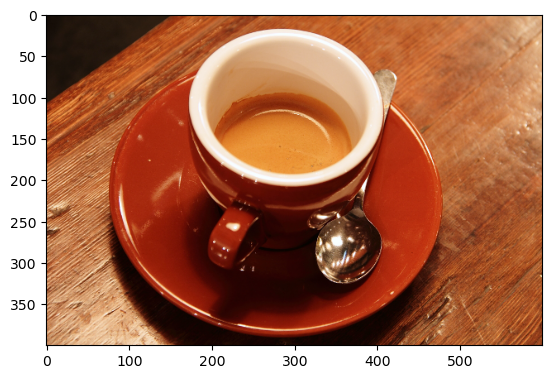

In [2]:
sample_image = skimage.data.coffee()

size = sample_image.shape
print("sample image shape: ", sample_image.shape)

plt.imshow(sample_image.astype('uint8'));

### A simple convolution filter

Before we start working on training any models, let's look at applying a convolution filter to an image. We'll use the `Conv2D` layer from Keras to do this.

In [3]:
from tensorflow.keras.layers import Conv2D

In [4]:
conv = Conv2D(filters=3, kernel_size=(5, 5), padding="same")

Remember: in Keras, `None` is used as a marker for tensor dimensions with dynamic size. In this case `batch_size`, `width` and `height` are all dynamic: they can depend on the input. This is a neat feature of convolutional neural networks: the same model can be used to process images of any size, because all we have to do is slide the convolutional filter across the image as much as necessary.

In [5]:
sample_image.shape

(400, 600, 3)

In [6]:
img_in = np.expand_dims(sample_image, 0).astype(float)
img_in.shape

(1, 400, 600, 3)

In [7]:
img_out = conv(img_in) # Apply the convolutional filter

The output is a tensorflow Eager Tensor - a special data structure that is used to represent the result of operations in TensorFlow. It is not a numpy array, but it can be converted to one using the `.numpy()` method:

In [8]:
np_img_out = img_out[0].numpy()
print(type(np_img_out))
print(np_img_out.shape)

<class 'numpy.ndarray'>
(400, 600, 3)


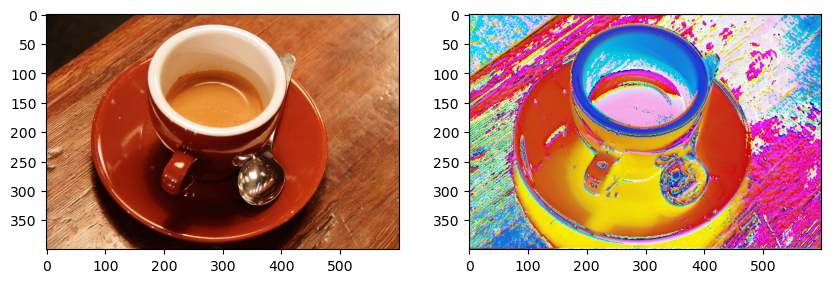

In [9]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(sample_image.astype('uint8'))
ax1.imshow(np_img_out.astype('uint8'));

As we can see, our convolutional filter was initialized randomly, so our output doesn't contain any specific meaning. Each pixel is a random combination of the pixels in the input image, in a 5x5 window.

Let's instead take a look at a convolutional feature with a clear purpose. We can build a kernel ourselves, by defining a function which will be passed to `Conv2D` Layer.
We'll create an array with 1/25 for filters, with each channel seperated. Before you move to the next cell, can you guess what this filter will do?

In [10]:
def my_kernel(shape=(5, 5, 3, 3), dtype=None):
    array = np.zeros(shape=shape, dtype="float32")
    array[:, :, 0, 0] = 1 / 25
    array[:, :, 1, 1] = 1 / 25
    array[:, :, 2, 2] = 1 / 25
    return array

Now we can use this function to initialize a `Conv2D` layer:

In [11]:
conv = Conv2D(filters=3, kernel_size=(5, 5), padding="same", kernel_initializer=my_kernel)

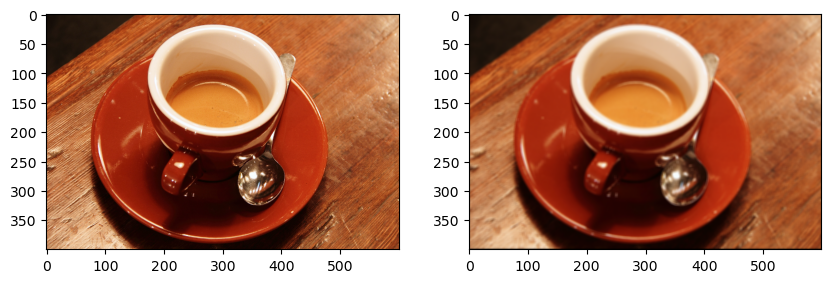

In [12]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(img_in[0].astype('uint8'))

img_out = conv(img_in)
np_img_out = img_out[0].numpy()
ax1.imshow(np_img_out.astype('uint8'));

Hopefully you can tell what this filter does!

**Exercise**
- There are a number of settings when we define our Conv2D layer. Try changing the following parameters to get a sense of how they impact the result:
- kernel_size: try different sizes
- padding: try 'valid' instead of 'same' (hint: this may change the size of the output)

In [13]:
# Different kernel size
conv = Conv2D(filters=3, kernel_size=(3, 3), padding="same", kernel_initializer=my_kernel)

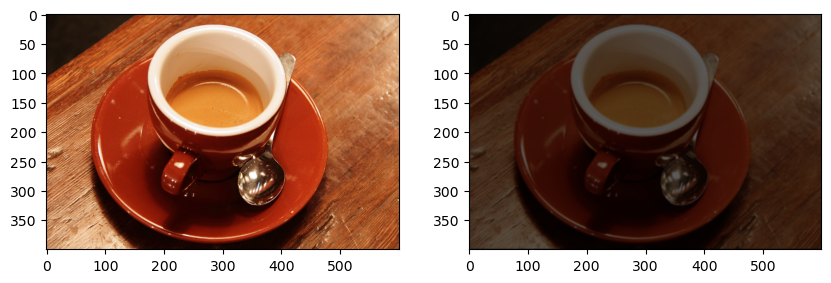

In [14]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(img_in[0].astype('uint8'))

img_out = conv(img_in)
np_img_out = img_out[0].numpy()
ax1.imshow(np_img_out.astype('uint8'));

In [15]:
# Different kernel size
conv = Conv2D(filters=3, kernel_size=(3, 3), padding="valid", kernel_initializer=my_kernel)

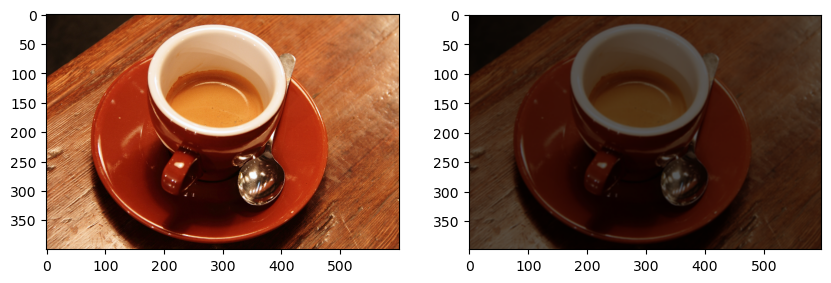

In [16]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(img_in[0].astype('uint8'))

img_out = conv(img_in)
np_img_out = img_out[0].numpy()
ax1.imshow(np_img_out.astype('uint8'));

### Working on edge detection on Grayscale image

Using a grayscale image, let's build an "edge detector" using a convolutional filter. Some filters pre-date the deep learning era and are still used today. For example, the Sobel filter is used to detect edges in images. These easy-to-compute filters were used in the early days of computer vision and are still useful now.

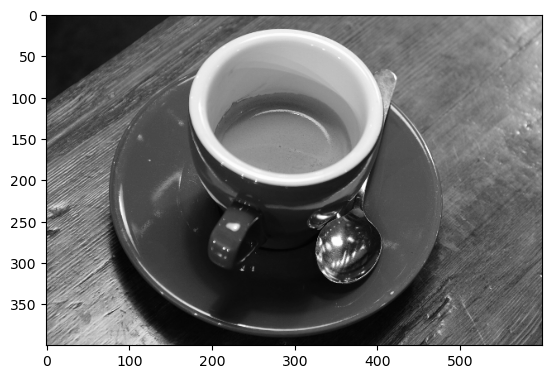

In [17]:
# convert image to greyscale
grey_sample_image = sample_image.mean(axis=2)

# add the channel dimension even if it's only one channel so
# to be consistent with Keras expectations.
grey_sample_image = grey_sample_image[:, :, np.newaxis]

# matplotlib does not like the extra dim for the color channel
# when plotting gray-level images. Let's use squeeze:
plt.imshow(np.squeeze(grey_sample_image.astype(np.uint8)),
           cmap=plt.cm.gray);

**Exercise**
- Build an edge detector using `Conv2D` on greyscale image by defining the kernel inside `my_kernel`.
- You may experiment with several kernels to find a way to detect edges. The following article contains specific examples of kernels that you can use:
- https://en.wikipedia.org/wiki/Kernel_(image_processing)
- Try different kernels and see the impact on the output.

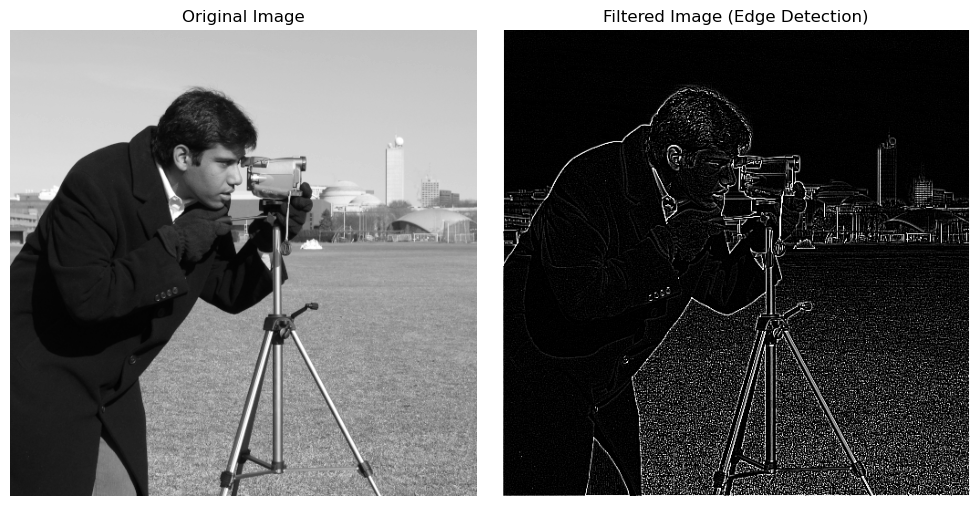

In [20]:
from tensorflow.keras.layers import Conv2D
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import skimage.data

grey_sample_image = skimage.data.camera()

# Edge detection kernel (Sobel-like)
def edge_detection_kernel(shape=(3, 3, 1, 1), dtype=None):
    array = np.array([[-1, -1, -1],
                      [-1,  8, -1],
                      [-1, -1, -1]], dtype=dtype)
    array = array.reshape(*shape)
    return array

# Create the kernel initializer function
def my_kernel_initializer(shape, dtype=None):
    # Convert TensorFlow dtype to NumPy dtype if needed
    if dtype is not None:
        if hasattr(dtype, 'as_numpy_dtype'):
            numpy_dtype = dtype.as_numpy_dtype
        else:
            numpy_dtype = dtype
    else:
        numpy_dtype = np.float32
    return edge_detection_kernel(shape, numpy_dtype)

# Create the Conv2D layer
conv = Conv2D(filters=1, kernel_size=(3, 3), padding="same", 
              kernel_initializer=my_kernel_initializer, use_bias=False)

# Prepare the input image
# Need to add channel dimension and convert to float32
img_expanded = np.expand_dims(grey_sample_image, axis=-1)  # Add channel dimension
img_in = np.expand_dims(img_expanded, axis=0)  # Add batch dimension
img_in = img_in.astype(np.float32)  # Convert to float32

# Apply the convolutional filter
img_out = conv(img_in)

# Convert to numpy array and squeeze dimensions
np_img_out = np.squeeze(img_out.numpy())

# Plot the results
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))

ax0.imshow(grey_sample_image, cmap='gray')
ax0.set_title('Original Image')
ax0.axis('off')

# For the filtered image, we might need to normalize for better visualization
# Since edge detection can produce negative values
img_display = np.clip(np_img_out, 0, 255).astype(np.uint8)
ax1.imshow(img_display, cmap='gray')
ax1.set_title('Filtered Image (Edge Detection)')
ax1.axis('off')

plt.tight_layout()
plt.show()


### Pooling and strides with convolutions

**Exercise**
- Use `MaxPool2D` to apply a 2x2 max pool with strides 2 to the image. What is the impact on the shape of the image?
- Use `AvgPool2D` to apply an average pooling.
- Is it possible to compute a max pooling and an average pooling with well chosen kernels?

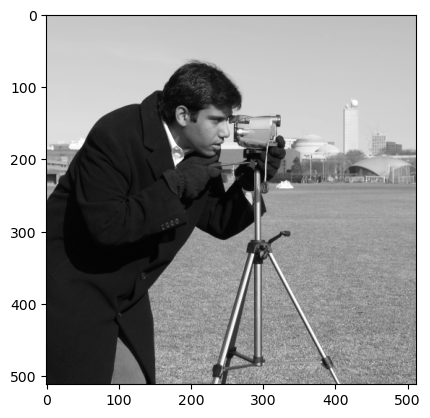

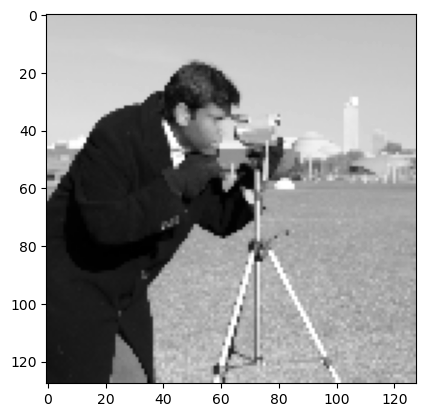

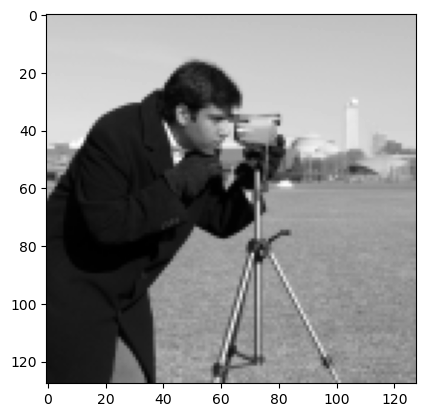

In [21]:
from tensorflow.keras.layers import MaxPool2D, AvgPool2D

# You can use `img_in` from above as input to the pooling layers

plt.figure()
plt.imshow(np.squeeze(grey_sample_image.astype(np.uint8)),
           cmap=plt.cm.gray);

pool = MaxPool2D(pool_size=(4, 4), strides=(4, 4), padding="valid")

img_out = pool(img_in)
np_img_out = img_out[0].numpy()

plt.figure()
plt.imshow(np.squeeze(np_img_out.astype(np.uint8)),
              cmap=plt.cm.gray);

pool = AvgPool2D(pool_size=(4, 4), strides=(4, 4), padding="valid")

img_out = pool(img_in)
np_img_out = img_out[0].numpy()

plt.figure()
plt.imshow(np.squeeze(np_img_out.astype(np.uint8)),
                cmap=plt.cm.gray);

## Loading a JPEG file as a numpy array

Let's use [scikit-image](http://scikit-image.rg) to load the content of a JPEG file into a numpy array:

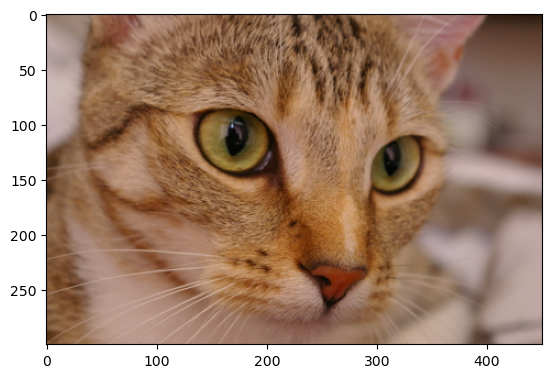

In [22]:
from skimage.io import imread

image = skimage.data.cat()
plt.imshow(image);

## Resizing images, handling data types and dynamic ranges

While convolutions can handle inputs of any size, it is often useful to resize images to a fixed size. This is particularly important for training deep learning models:

- for **image classification**, most networks expect a specific **fixed input size**;

- for **object detection** and instance segmentation, networks have more flexibility but the image should have **approximately the same size as the training set images**.

Furthermore **large images can be much slower to process** than smaller images (the number of pixels varies quadratically with the height and width).

In [23]:
from skimage.transform import resize

lowres_image = resize(image, (50, 50), mode='reflect', anti_aliasing=True)
lowres_image.shape

(50, 50, 3)

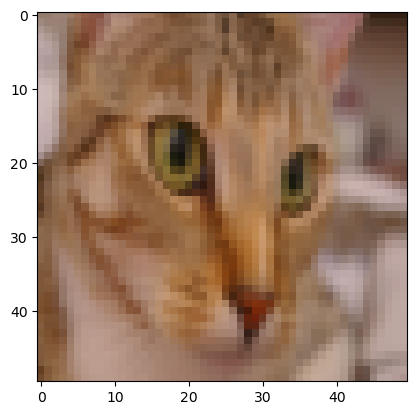

In [24]:
plt.imshow(lowres_image, interpolation='nearest');

The values of the pixels of the low resolution image are computed from by combining the values of the pixels in the high resolution image. The result is therefore represented as floating points.

## Using a pretrained model

Objectives:

- Load a pre-trained ResNet50 pre-trained model using Keras Zoo
- Use the model to classify an image
- Use the model to classify an image from the webcam

Let's start with loading ResNet50, a well-established method for image classification. The ResNet50 "application" takes two key parameters here: firstly, `include_top` indicates whether we want to include the last layer of the network (the classification layer) or not. Secondly, `weights` indicates whether we want to load the weights of a model that has been pre-trained on ImageNet or not.

In [25]:
from tensorflow.keras.applications.resnet50 import ResNet50

model = ResNet50(include_top=True, weights='imagenet')
model.compile(optimizer='sgd', loss='categorical_crossentropy')

102967424/102967424 [==============================] - 22s 0us/step


In [26]:
print(model.summary())

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                           

### Classification of an image

**Exercise**
- Reshape the `cat` image to the shape `(224, 224, 3)` using `resize` from `skimage.transform`
- Use `preprocess_input` from `tensorflow.keras.applications.imagenet_utils` to preprocess the image
- Use `predict` to classify the image

Documentation for each method:
- [resize](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize)
- [preprocess_input](https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/preprocess_input)
- [predict](https://www.tensorflow.org/api_docs/python/tf/keras/Model#predict)

Original image shape: (300, 451, 3)
Resized image shape: (224, 224, 3)
Batch shape: (1, 224, 224, 3)
Preprocessed shape: (1, 224, 224, 3)
Preprocessed value range: [-119.68, 86.32]
35363/35363 [==============================] - 0s 0s/step

Top 5 Predictions:
1. Egyptian_cat: 0.9551 (95.51%)
2. tiger_cat: 0.0185 (1.85%)
3. tabby: 0.0180 (1.80%)
4. shower_cap: 0.0055 (0.55%)
5. plastic_bag: 0.0011 (0.11%)


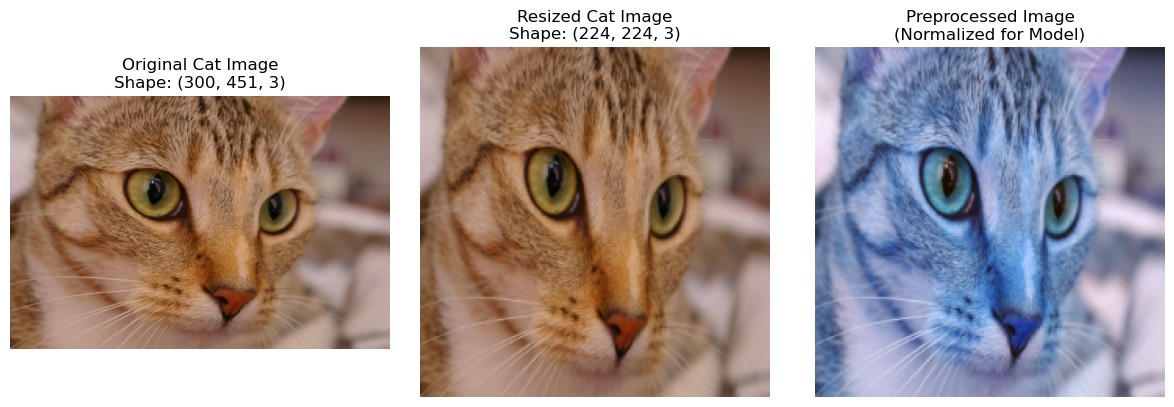

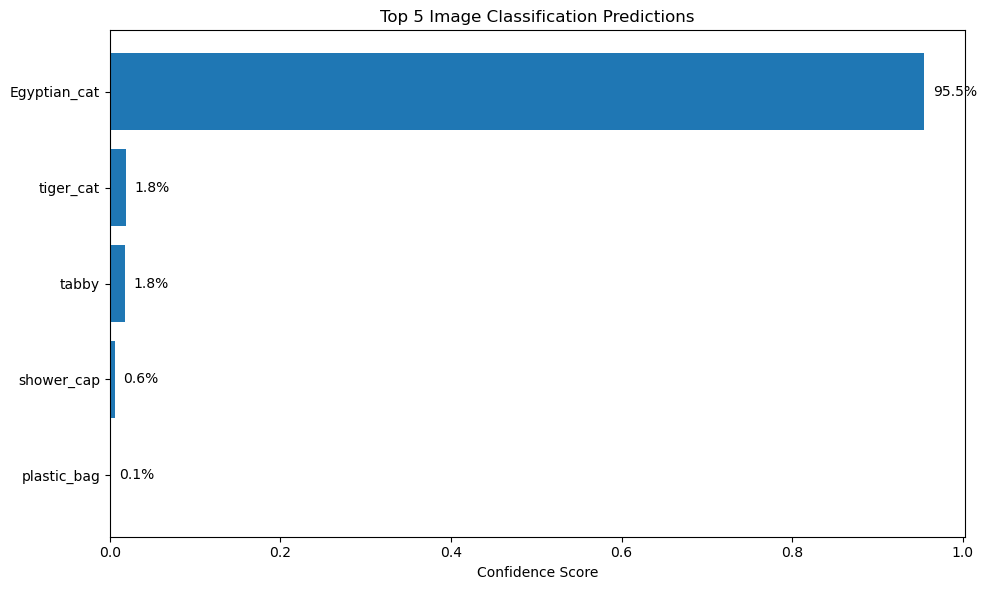

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from skimage import data
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.imagenet_utils import preprocess_input, decode_predictions

# Load the cat image from skimage
cat = data.chelsea()  # This loads a cat image

# Display the original image
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(cat)
plt.title(f'Original Cat Image\nShape: {cat.shape}')
plt.axis('off')

# Step 1: Reshape the cat image to (224, 224, 3)
cat_resized = resize(cat, (224, 224, 3), anti_aliasing=True)

# Convert to the range [0, 255] and ensure correct dtype
cat_resized = (cat_resized * 255).astype(np.uint8)

# Display the resized image
plt.subplot(1, 3, 2)
plt.imshow(cat_resized)
plt.title(f'Resized Cat Image\nShape: {cat_resized.shape}')
plt.axis('off')

# Step 2: Use preprocess_input to preprocess the image
# First, we need to add a batch dimension
cat_batch = np.expand_dims(cat_resized, axis=0)  # Shape: (1, 224, 224, 3)

# Preprocess the input (this normalizes the image for the specific model)
cat_preprocessed = preprocess_input(cat_batch.astype(np.float32))

print(f"Original image shape: {cat.shape}")
print(f"Resized image shape: {cat_resized.shape}")
print(f"Batch shape: {cat_batch.shape}")
print(f"Preprocessed shape: {cat_preprocessed.shape}")
print(f"Preprocessed value range: [{cat_preprocessed.min():.2f}, {cat_preprocessed.max():.2f}]")

# Load a pre-trained ResNet50 model
model = ResNet50(weights='imagenet', include_top=True)

# Step 3: Use predict to classify the image
predictions = model.predict(cat_preprocessed)

# Decode the predictions to get human-readable labels
decoded_predictions = decode_predictions(predictions, top=5)[0]

print("\nTop 5 Predictions:")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"{i+1}. {label}: {score:.4f} ({score*100:.2f}%)")

# Visualize the preprocessed image (for demonstration)
# Note: preprocessed image values are normalized and may look different
plt.subplot(1, 3, 3)
# For visualization, we need to denormalize the preprocessed image
cat_viz = cat_preprocessed[0].copy()
# Simple denormalization (this is approximate since preprocess_input does complex normalization)
cat_viz = (cat_viz - cat_viz.min()) / (cat_viz.max() - cat_viz.min())
plt.imshow(cat_viz)
plt.title('Preprocessed Image\n(Normalized for Model)')
plt.axis('off')

plt.tight_layout()
plt.show()

# Create a bar plot of the top predictions
plt.figure(figsize=(10, 6))
labels = [pred[1] for pred in decoded_predictions]
scores = [pred[2] for pred in decoded_predictions]

plt.barh(range(len(labels)), scores)
plt.yticks(range(len(labels)), labels)
plt.xlabel('Confidence Score')
plt.title('Top 5 Image Classification Predictions')
plt.gca().invert_yaxis()  # Highest confidence at the top

# Add percentage labels on the bars
for i, score in enumerate(scores):
    plt.text(score + 0.01, i, f'{score*100:.1f}%', va='center')

plt.tight_layout()
plt.show()

##  Taking snapshots from the webcam

For this section, we will take an image from your laptop webcam and classify it. If you feel uncomfortable doing this section, you can skip it and use a photo of your choice from the web instead.

### Exercise

Apply the same preprocessing as before and classify the image. What are your results?

Original image shape: (2583, 2939, 3)
Resized image shape: (224, 224, 3)
Batch shape: (1, 224, 224, 3)
Preprocessed shape: (1, 224, 224, 3)
Preprocessed value range: [-123.67, -102.96]
1/1 [==============================] - 2s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).



Top 5 Predictions:
1. web_site: 0.0563 (5.63%)
2. matchstick: 0.0475 (4.75%)
3. nematode: 0.0471 (4.71%)
4. digital_clock: 0.0470 (4.70%)
5. television: 0.0303 (3.03%)


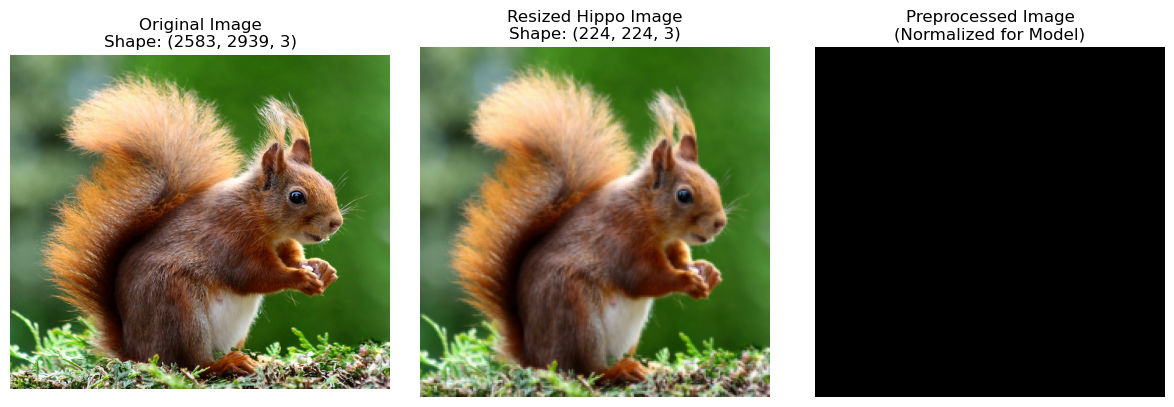

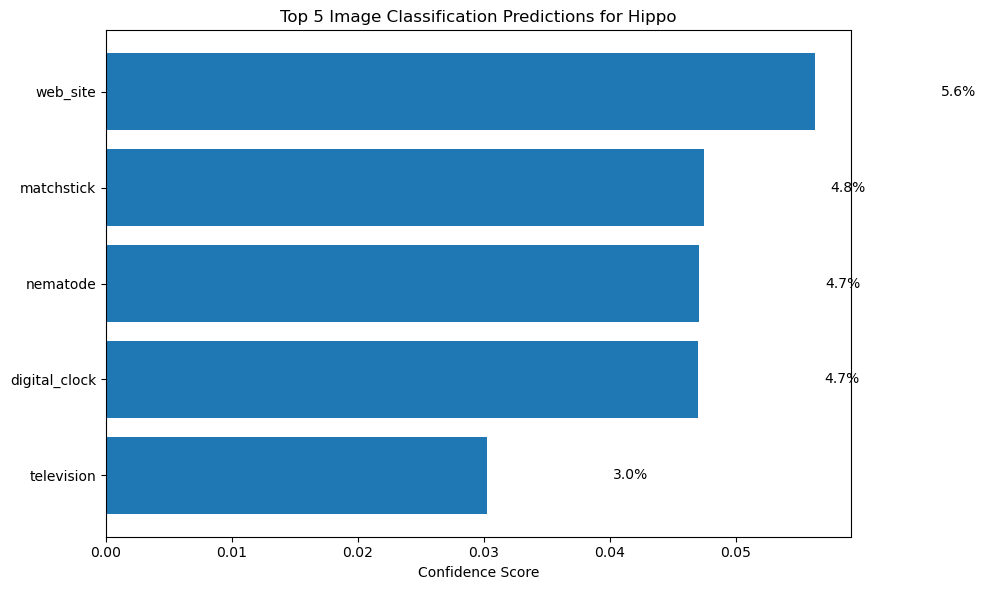

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from skimage import io
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.imagenet_utils import preprocess_input, decode_predictions
import requests
from PIL import Image
from io import BytesIO

# Load an image from a local file path
image_path = r"C:\Users\laksh\Downloads\pexels-pixabay-47547.jpg"

# Load the image using PIL directly
image_pil = Image.open(image_path)
# Convert PIL image to numpy array
image = np.array(image_pil)

# If the image has an alpha channel, remove it
if image.shape[-1] == 4:
    image = image[:, :, :3]

# Display the original image
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title(f'Original Image\nShape: {image.shape}')
plt.axis('off')

# Step 1: Reshape the hippo image to (224, 224, 3)
image_resized = resize(image, (224, 224, 3), anti_aliasing=True)
# Convert to the range [0, 255] and ensure correct dtype
hippo_resized = (image_resized * 255).astype(np.uint8)

# Display the resized image
plt.subplot(1, 3, 2)
plt.imshow(image_resized)
plt.title(f'Resized Hippo Image\nShape: {image_resized.shape}')
plt.axis('off')

# Step 2: Use preprocess_input to preprocess the image
# First, we need to add a batch dimension
image_batch = np.expand_dims(image_resized, axis=0)  # Shape: (1, 224, 224, 3)
# Preprocess the input (this normalizes the image for the specific model)
image_preprocessed = preprocess_input(image_batch.astype(np.float32))

print(f"Original image shape: {image.shape}")
print(f"Resized image shape: {image_resized.shape}")
print(f"Batch shape: {image_batch.shape}")
print(f"Preprocessed shape: {image_preprocessed.shape}")
print(f"Preprocessed value range: [{image_preprocessed.min():.2f}, {image_preprocessed.max():.2f}]")

# Load a pre-trained ResNet50 model
model = ResNet50(weights='imagenet', include_top=True)

# Step 3: Use predict to classify the image
predictions = model.predict(image_preprocessed)

# Decode the predictions to get human-readable labels
decoded_predictions = decode_predictions(predictions, top=5)[0]

print("\nTop 5 Predictions:")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"{i+1}. {label}: {score:.4f} ({score*100:.2f}%)")

# Visualize the preprocessed image (for demonstration)

plt.subplot(1, 3, 3)
# For visualization, we need to denormalize the preprocessed image
image_viz = image_preprocessed[0].copy()
# Simple denormalization (this is approximate since preprocess_input does complex normalization)
hippo_viz = (image_viz - image_viz.min()) / (image_viz.max() - image_viz.min())
plt.imshow(image_viz)
plt.title('Preprocessed Image\n(Normalized for Model)')
plt.axis('off')

plt.tight_layout()
plt.show()

# Create a bar plot of the top predictions
plt.figure(figsize=(10, 6))
labels = [pred[1] for pred in decoded_predictions]
scores = [pred[2] for pred in decoded_predictions]

plt.barh(range(len(labels)), scores)
plt.yticks(range(len(labels)), labels)
plt.xlabel('Confidence Score')
plt.title('Top 5 Image Classification Predictions for Hippo')
plt.gca().invert_yaxis()  # Highest confidence at the top

# Add percentage labels on the bars
for i, score in enumerate(scores):
    plt.text(score + 0.01, i, f'{score*100:.1f}%', va='center')

plt.tight_layout()
plt.show()